## Library Example

In [15]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import pandas as pd
import io 
cns_source = """sample_id, chrom, start, end, CN1, CN2
s1, chr19, 1000000, 3000000, 1,
s1, chr19, 3000000, 12000000, 1, 1
s1, chr19, 12000000, 14000000, , 1
s1, chr19, 14000000, 21000000, 3, 1
s1, chr19, 21000000, 25000000, 3, 
s1, chr19, 28000000, 58500000, 3,
s2, chr19, 1000000, 24000000, 2,
s2, chr19, 29000000, 58000000, 0,
"""

In [17]:
raw_cns_df = pd.read_csv(io.StringIO(cns_source.strip()), sep=',\s*', engine='python')
print(raw_cns_df.head())

  sample_id  chrom     start       end  CN1  CN2
0        s1  chr19   1000000   3000000  1.0  NaN
1        s1  chr19   3000000  12000000  1.0  1.0
2        s1  chr19  12000000  14000000  NaN  1.0
3        s1  chr19  14000000  21000000  3.0  1.0
4        s1  chr19  21000000  25000000  3.0  NaN


In [18]:
from cns import main_fill_imp

cns_df = main_fill_imp(raw_cns_df, add_missing_chromosomes=False)
print(cns_df.head())

  sample_id  chrom     start       end  CN1  CN2
0        s1  chr19         0  13000000    1    1
1        s1  chr19  13000000  59128983    3    1
2        s2  chr19         0  26500000    2    0
3        s2  chr19  26500000  59128983    0    0


In [19]:
from cns import main_seg_agg
constistent_df = main_seg_agg(cns_df, merge_dist=0, remove_segs="gaps")
print(raw_cns_df.head())

  sample_id  chrom     start       end  CN1  CN2
0        s1  chr19   1000000   3000000  1.0  NaN
1        s1  chr19   3000000  12000000  1.0  1.0
2        s1  chr19  12000000  14000000  NaN  1.0
3        s1  chr19  14000000  21000000  3.0  1.0
4        s1  chr19  21000000  25000000  3.0  NaN


TypeError: _check_fig_input() missing 1 required positional argument: 'assembly'

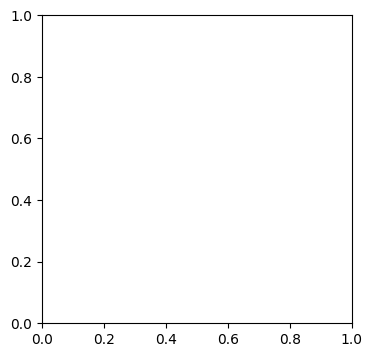

In [20]:
from cns.display.plot import fig_heatmap
fig_heatmap(constistent_df, cn_columns=['CN1', 'CN2'], chrom='chr19');

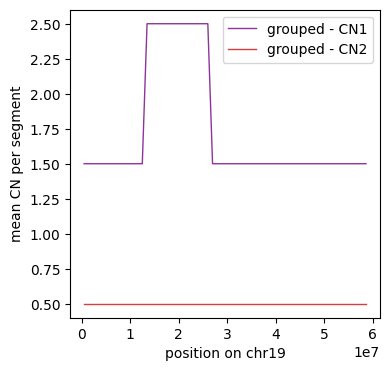

In [ ]:
from cns.display import fig_lines
from cns.process import group_samples
split_df = main_seg_agg(cns_df, split_size=1000000, remove_segs="gaps")
group_df = group_samples(split_df)
fig_lines(group_df, chrom='chr19');

In [ ]:
group_df.head()

NameError: name 'group_df' is not defined